<a href="https://colab.research.google.com/github/AlexandraRawrrr/python_for_ds_tasks/blob/main/Copy_of_HW_11_2_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/yulu_rental.csv')

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [ ]:
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [6]:
monthly_rent = df['count'].resample('ME').mean()

monthly_rent.head()

,count
datetime,
2011-01-31,54.645012
2011-02-28,73.641256
2011-03-31,86.849776
2011-04-30,111.026374
2011-05-31,174.809211


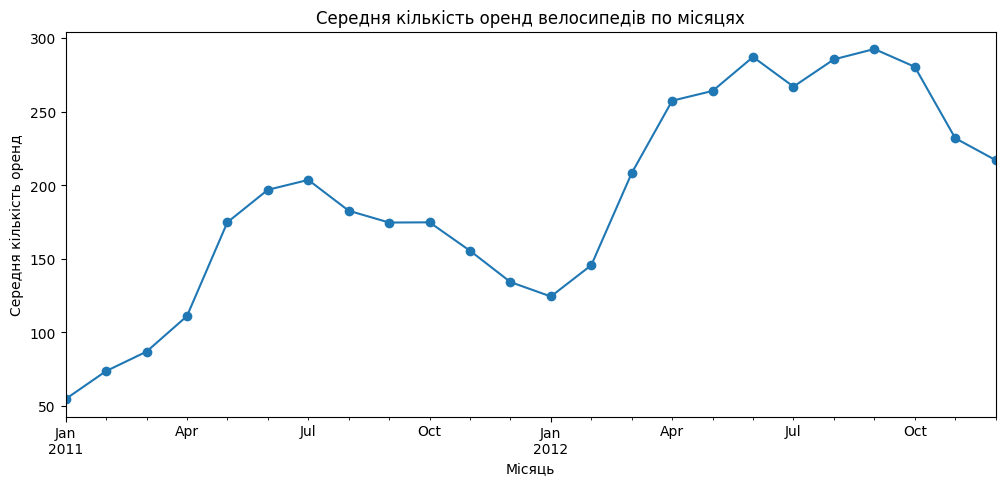

In [7]:
monthly_rent.plot(
    marker='o',
    figsize=(12, 5),
    title='Середня кількість оренд велосипедів по місяцях'
)

plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд')
plt.show()

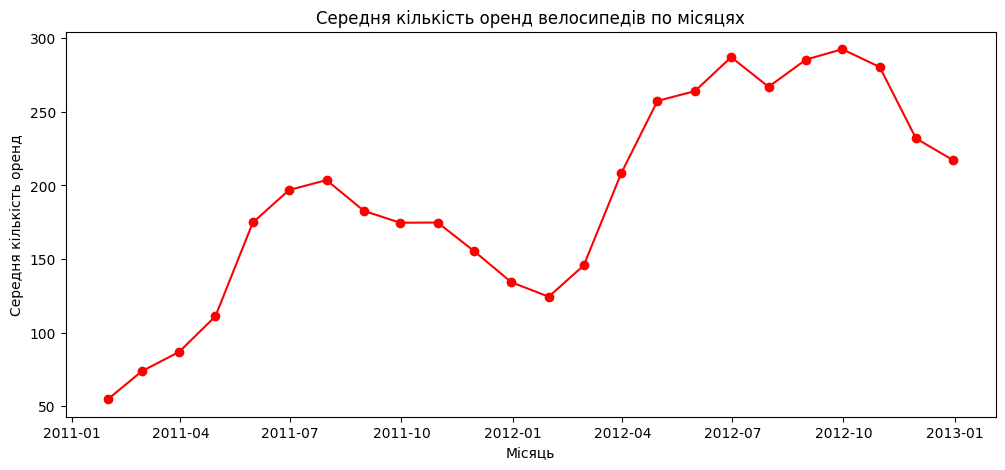

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_rent.index,
    monthly_rent.values,
    marker='o',
    color = 'red'
)

plt.title('Середня кількість оренд велосипедів по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд')

plt.show()

Обидва графіки показують однакові дані та мають схожу форму, оскільки побудовані на основі одного набору значень. Відмінність присутня у способі побудови та налаштування графіка. Мені до вподоби більше 2 графік Matplotlib, тут більше деталей і він трохи прємніший оку, хоча Pandas просто компактніше.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [19]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

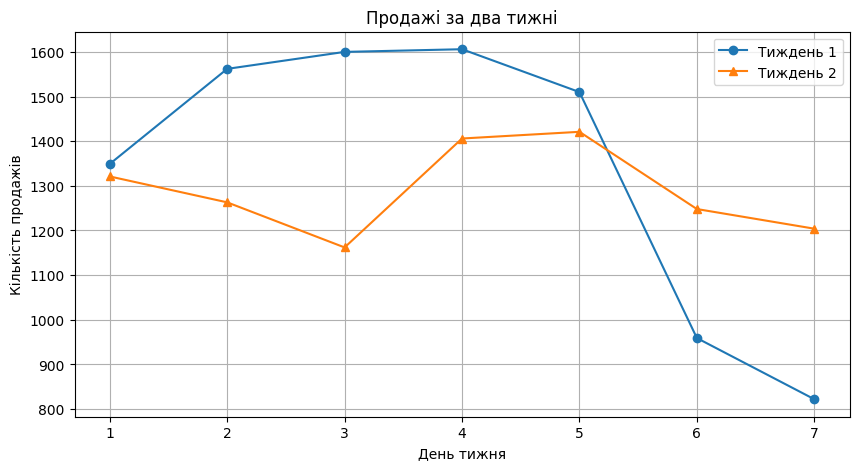

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(days, sales_week1, marker='o', label='Тиждень 1')
plt.plot(days, sales_week2, marker='^', label='Тиждень 2')

plt.title('Продажі за два тижні')
plt.xlabel('День тижня')
plt.ylabel('Кількість продажів')

plt.legend()
plt.grid(True)

plt.show()

1. Судячи з графіку, в який тиждень проодажі були стабільніше?
  Судячи з графіку, другий тиждень був стабільніше.
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.
  Так, висновок можна підтвердити обчисленнями. Для першого тижня різниця між максимальним і мінімальним значенням становить 1606 − 822 = 784 продажі. Для другого тижня: 1421 − 1162 = 259 продажів. Отже, діапазон коливань у другому тижні значно менший, тому продажі були стабільнішими.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

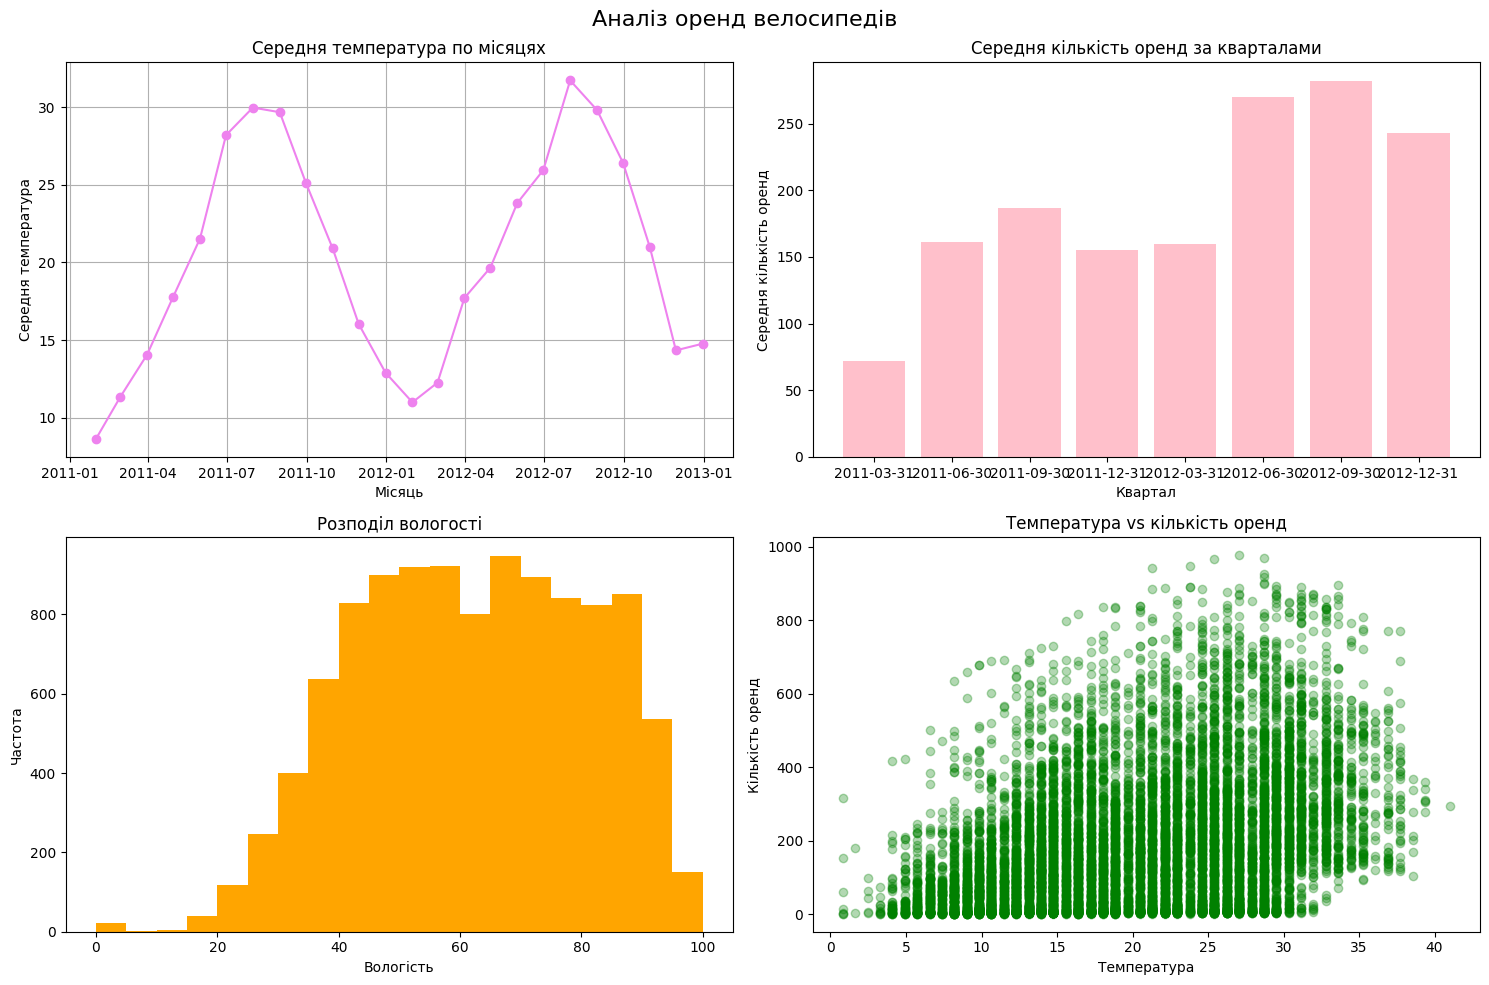

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Лінійний графік середньої температури щомісячно
monthly_temp = df['temp'].resample('ME').mean()

axes[0, 0].plot(monthly_temp.index, monthly_temp.values, marker='o', color='violet')
axes[0, 0].set_title('Середня температура по місяцях')
axes[0, 0].set_xlabel('Місяць')
axes[0, 0].set_ylabel('Середня температура')
axes[0, 0].grid(True)

# 2. Стовпчикова діаграма середньої кількості оренд за кварталами
quarterly_rent = df['count'].resample('QE').mean()

axes[0, 1].bar(quarterly_rent.index.astype(str), quarterly_rent.values, color='pink')
axes[0, 1].set_title('Середня кількість оренд за кварталами')
axes[0, 1].set_xlabel('Квартал')
axes[0, 1].set_ylabel('Середня кількість оренд')

# 3. Гістограма вологості
axes[1, 0].hist(df['humidity'], bins=20, color='orange')
axes[1, 0].set_title('Розподіл вологості')
axes[1, 0].set_xlabel('Вологість')
axes[1, 0].set_ylabel('Частота')

# 4. Scatter plot: температура vs кількість оренд
axes[1, 1].scatter(df['temp'], df['count'], alpha=0.3, color='green')
axes[1, 1].set_title('Температура vs кількість оренд')
axes[1, 1].set_xlabel('Температура')
axes[1, 1].set_ylabel('Кількість оренд')

# Загальна назва dashboard
fig.suptitle('Аналіз оренд велосипедів', fontsize=16)

plt.tight_layout()
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

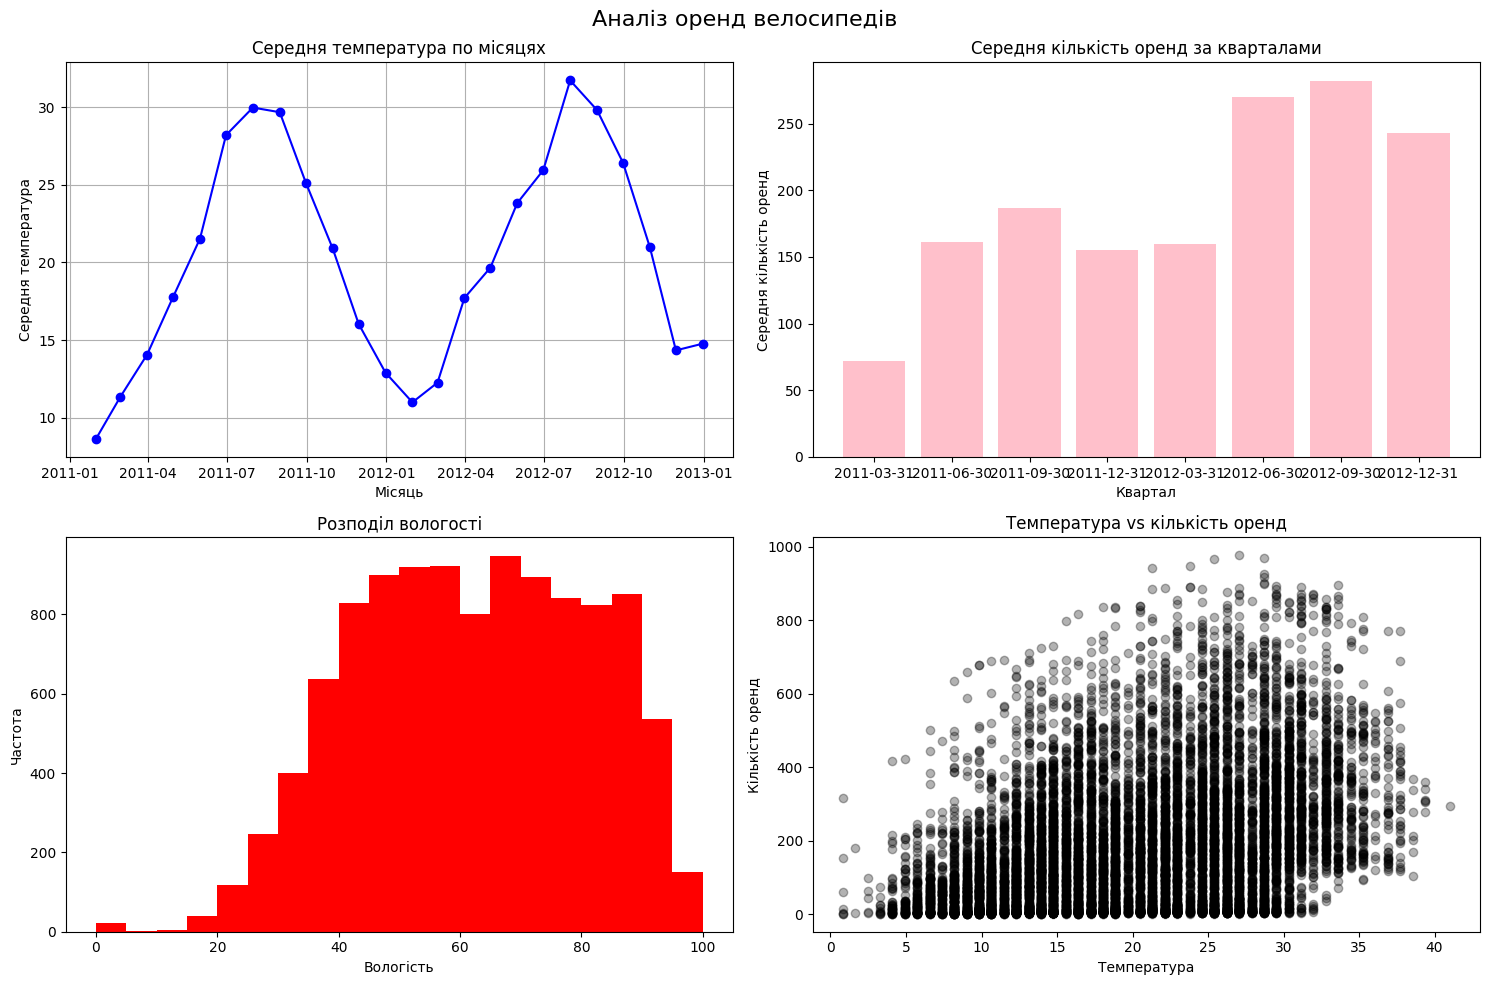

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# 1. Лінійний графік середньої температури щомісячно
monthly_temp = df['temp'].resample('ME').mean()

ax[0, 0].plot(monthly_temp.index, monthly_temp.values, marker='o', color='blue')
ax[0, 0].set_title('Середня температура по місяцях')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Середня температура')
ax[0, 0].grid(True)

# 2. Стовпчикова діаграма середньої кількості оренд за кварталами
quarterly_rent = df['count'].resample('QE').mean()

ax[0, 1].bar(quarterly_rent.index.astype(str), quarterly_rent.values, color='pink')
ax[0, 1].set_title('Середня кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість оренд')

# 3. Гістограма вологості
ax[1, 0].hist(df['humidity'], bins=20, color='red')
ax[1, 0].set_title('Розподіл вологості')
ax[1, 0].set_xlabel('Вологість')
ax[1, 0].set_ylabel('Частота')

# 4. Scatter plot: температура vs кількість оренд
ax[1, 1].scatter(df['temp'], df['count'], alpha=0.3, color='black')
ax[1, 1].set_title('Температура vs кількість оренд')
ax[1, 1].set_xlabel('Температура')
ax[1, 1].set_ylabel('Кількість оренд')

fig.suptitle('Аналіз оренд велосипедів', fontsize=16)

plt.tight_layout()
plt.show()

plt.subplot() використовується для створення окремих графіків по одному та дозволяє працювати з ними послідовно. plt.subplots() одразу створює фігуру (fig) та набір об'єктів графіків (ax), з якими можна працювати окремо. Такий підхід зручніший, коли потрібно створити багато графіків та налаштовувати кожен із них окремо.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

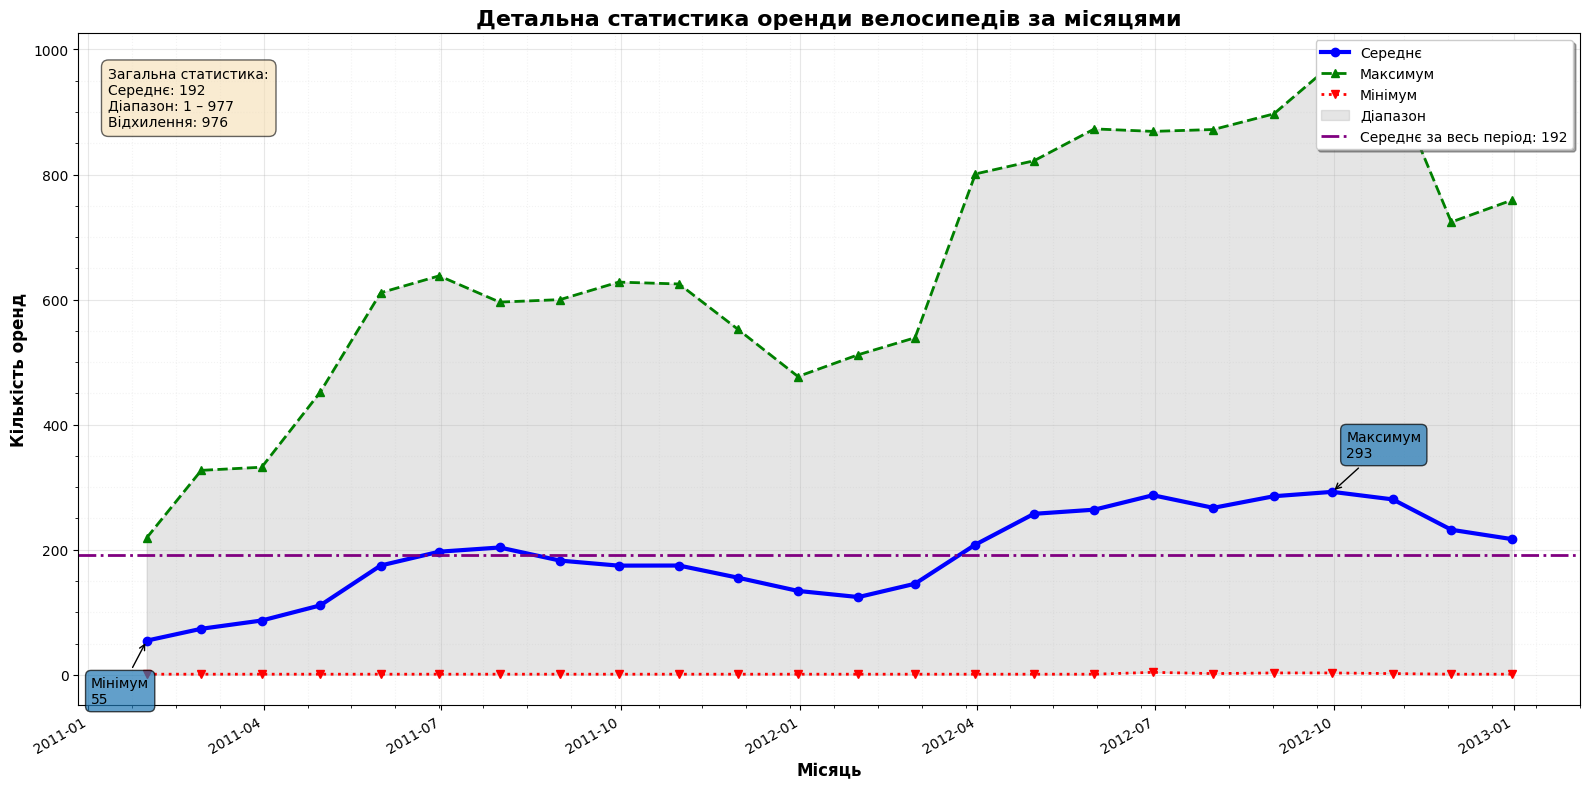

In [28]:
# Середнє, мінімальне та максимальне значення оренд по місяцях
monthly_mean = df['count'].resample('ME').mean()
monthly_max = df['count'].resample('ME').max()
monthly_min = df['count'].resample('ME').min()

# Загальна статистика
overall_mean = df['count'].mean()
overall_min = df['count'].min()
overall_max = df['count'].max()

# Створюємо графік
fig, ax = plt.subplots(figsize=(16, 8))

# 1. Три лінії
ax.plot(
    monthly_mean.index,
    monthly_mean.values,
    color='blue',
    marker='o',
    linewidth=3,
    label='Середнє'
)

ax.plot(
    monthly_max.index,
    monthly_max.values,
    color='green',
    marker='^',
    linestyle='--',
    linewidth=2,
    label='Максимум'
)

ax.plot(
    monthly_min.index,
    monthly_min.values,
    color='red',
    marker='v',
    linestyle=':',
    linewidth=2,
    label='Мінімум'
)

# 2. Заливка області між мінімумом і максимумом
ax.fill_between(
    monthly_max.index,
    monthly_min.values,
    monthly_max.values,
    color='gray',
    alpha=0.2,
    label='Діапазон'
)

# 3. Горизонтальна лінія загального середнього
ax.axhline(
    overall_mean,
    color='purple',
    linestyle='-.',
    linewidth=2,
    label=f'Середнє за весь період: {overall_mean:.0f}'
)

# Знаходимо місяці з найбільшим і найменшим середнім
max_month = monthly_mean.idxmax()
max_value = monthly_mean.max()

min_month = monthly_mean.idxmin()
min_value = monthly_mean.min()

# 4. Анотація максимального середнього
ax.annotate(
    f'Максимум\n{max_value:.0f}',
    xy=(max_month, max_value),
    xytext=(10, 25),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->'),
    bbox=dict(boxstyle='round,pad=0.4', alpha=0.7)
)

# 5. Анотація мінімального середнього
ax.annotate(
    f'Мінімум\n{min_value:.0f}',
    xy=(min_month, min_value),
    xytext=(-40, -45),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->'),
    bbox=dict(boxstyle='round,pad=0.4', alpha=0.7)
)

# 6. Подвійна сітка
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.15)

# 7. Назви та підписи
ax.set_title(
    'Детальна статистика оренди велосипедів за місяцями',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel(
    'Місяць',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Кількість оренд',
    fontsize=12,
    fontweight='bold'
)

# 8. Стилізована легенда
ax.legend(
    loc='upper right',
    frameon=True,
    shadow=True
)

# 9. Текстовий блок зі статистикою
stats_text = (
    f'Загальна статистика:\n'
    f'Середнє: {overall_mean:.0f}\n'
    f'Діапазон: {overall_min:.0f} – {overall_max:.0f}\n'
    f'Відхилення: {overall_max - overall_min:.0f}'
)

ax.text(
    0.02,
    0.95,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='wheat',
        alpha=0.6
    )
)

# Автоматичне форматування дат
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

1. Яка перевага додавання анотацій на графік?
  За допомогою анотацій можна одразу визначити ключові значення і показують, що вони означають. Це робить графік більш зрозумілим.
2. Для чого використовується fill_between()?
Використовується для заливки між максимумом і мінімомум значень, так ми бачимо наші коливання даних і іх діапазон.
3. Як текстовий блок допомагає в інтерпретації даних?
Це коротка вижимка найважливіших даних, які можуть бути корисними, а саме мінімальне значення. максимальне значення. середнє і діпазон. Таким чином не треба аналізувати весь графік.